Step 2: Libraries imported successfully!
Step 5: Datasets loaded! Found 100000 training images.
Step 7: DataLoaders created with batch size 64.
Step 6: Shape of one batch of images: torch.Size([64, 3, 224, 224])


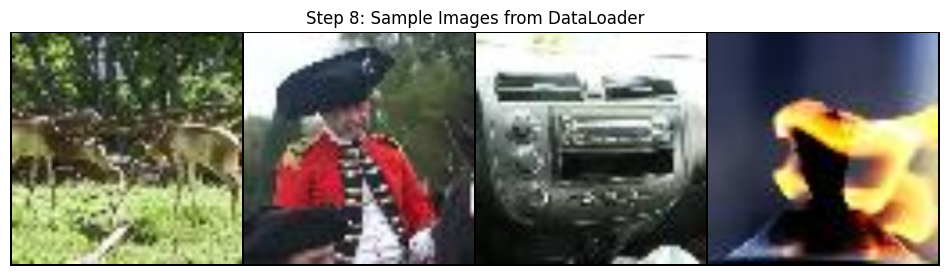

In [3]:
# ==========================================
# PHASE 1: ENVIRONMENT SETUP & DATA PREP
# ==========================================

# Step 1: Set up Kaggle Environment
# (Note: You do this in the Kaggle UI by selecting "Accelerator: GPU T4 x2" from the notebook settings)

# Step 2: Import Libraries
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print("Step 2: Libraries imported successfully!")

# Step 3: Load Dataset Path
# Make sure you have added the TinyImageNet dataset to your Kaggle notebook.
# The path usually looks like this in Kaggle:
DATA_DIR = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200' 
train_dir = os.path.join(DATA_DIR, 'train')
val_dir = os.path.join(DATA_DIR, 'val')

# Step 4: Define Transforms
# The assignment requires the image size to be 224x224[cite: 33].
# We convert images to PyTorch Tensors, which automatically scales pixel values from 0-255 to 0.0-1.0.
my_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resizing TinyImageNet from 64x64 to 224x224
    transforms.ToTensor()          # Converts to tensor and scales to 0-1
])

# Step 5: Initialize Datasets
# ImageFolder automatically reads images from sub-folders and assigns them labels
try:
    train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=my_transforms)
    val_dataset = torchvision.datasets.ImageFolder(root=val_dir, transform=my_transforms)
    print(f"Step 5: Datasets loaded! Found {len(train_dataset)} training images.")
except Exception as e:
    print("Error loading dataset. Please check if DATA_DIR is correct for your Kaggle environment.")

# Step 7: Create DataLoaders
# The assignment requires a small batch size of 32-64 to fit on the Kaggle T4 GPUs[cite: 81].
BATCH_SIZE = 64 

# DataLoader batches the data, shuffles it, and loads it in parallel using num_workers
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Step 7: DataLoaders created with batch size {BATCH_SIZE}.")

# ==========================================
# TESTING AND VISUALIZATION (Steps 6 & 8)
# ==========================================

# Let's fetch one single batch of data from the train_loader to test everything
data_iterator = iter(train_loader)
images, labels = next(data_iterator)

# Step 6: Check Data Shape
# Shape should be [Batch_Size, Channels, Height, Width] -> [64, 3, 224, 224]
print(f"Step 6: Shape of one batch of images: {images.shape}")

# Step 8: Visualize Batch
# Let's write a simple function to show the first 4 images of our batch
def show_images(imgs, num_images=4):
    # Take only the first 'num_images'
    imgs = imgs[:num_images]
    
    # Make a grid of images
    grid = torchvision.utils.make_grid(imgs, nrow=4)
    
    # Convert PyTorch tensor to Numpy array for Matplotlib
    np_grid = grid.numpy()
    
    # PyTorch uses (Channels, Height, Width) but Matplotlib wants (Height, Width, Channels)
    # So we use np.transpose to rearrange the axes from (0, 1, 2) to (1, 2, 0)
    plt.figure(figsize=(12, 4))
    plt.imshow(np.transpose(np_grid, (1, 2, 0)))
    plt.axis('off') # Hide axes
    plt.title("Step 8: Sample Images from DataLoader")
    plt.show()

# Call the function to display
show_images(images)

In [4]:
# ==========================================
# PHASE 2: PATCHIFICATION & MASKING MODULE
# ==========================================
import torch
import torch.nn as nn

class PatchifyAndMask(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3):
        super().__init__()
        
        # Step 9: Define Patch Size and Image Size
        self.img_size = img_size
        self.patch_size = patch_size
        
        # Step 10: Calculate Dimensions
        # Total patches = (224 / 16) * (224 / 16) = 14 * 14 = 196
        self.num_patches = (img_size // patch_size) ** 2 
        
        # Patch dimension = 3 channels * 16 height * 16 width = 768
        self.patch_dim = in_channels * patch_size * patch_size 

    # Step 11: Implement `patchify` Method
    def patchify(self, imgs):
        """
        Takes an image tensor of shape [Batch, Channels, Height, Width]
        and converts it to a sequence of patches [Batch, Num_Patches, Patch_Dim]
        """
        p = self.patch_size
        # h = w = 224 // 16 = 14
        h = w = self.img_size // p 
        
        # 1. Reshape the image to separate the patches
        # From [Batch, 3, 224, 224] -> [Batch, 3, 14, 16, 14, 16]
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        
        # 2. Swap axes to group spatial dimensions (h, w) and patch pixels (p, p, 3)
        # We use torch.einsum for clean swapping. 'nchpwq->nhwpqc'
        # N=Batch, C=Channels, H=h, P=patch_h, W=w, Q=patch_w
        x = torch.einsum('nchpwq->nhwpqc', x)
        
        # 3. Flatten the spatial dimensions (14*14=196) and patch pixels (16*16*3=768)
        # Final shape: [Batch, 196, 768]
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
        
        return x

    # Step 12: Implement `random_masking` Method
    def random_masking(self, x, mask_ratio=0.75):
        """
        Takes the sequence of patches and hides 75% of them.
        x shape: [Batch, 196, 768]
        """
        N, L, D = x.shape  # N = Batch, L = 196 (Length), D = 768 (Dim)
        
        # Calculate exactly how many patches to keep (25%)
        # 196 * 0.25 = 49 patches
        len_keep = int(L * (1 - mask_ratio)) 
        
        # 1. Generate random noise for all 196 patches
        noise = torch.rand(N, L, device=x.device) 
        
        # 2. Sort the noise to get shuffled indices (smallest to largest)
        # ids_shuffle tells us the new random order of patches
        ids_shuffle = torch.argsort(noise, dim=1) 
        
        # 3. Create 'ids_restore' by sorting the shuffled indices again.
        # We MUST save this to put patches back in their correct grid position later!
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # 4. Keep only the first 49 indices from our shuffled list
        ids_keep = ids_shuffle[:, :len_keep]
        
        # 5. Gather the actual patch pixel data for those 49 indices
        # We have to expand ids_keep to match the 768 dimensions to copy the data properly
        x_kept = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # 6. Generate a binary mask tensor (1 for masked/hidden, 0 for visible)
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0 # Set first 49 to 0 (visible)
        
        # Unshuffle the mask so it matches the original image layout
        mask = torch.gather(mask, dim=1, index=ids_restore)

        # Return the 49 visible patches, the binary mask, and the restore indices
        return x_kept, mask, ids_restore

# ==========================================
# TESTING PHASE 2
# ==========================================

# Let's test this module with the batch of images we got from Phase 1!
print("--- Testing Phase 2 ---")

# Initialize the module
patcher = PatchifyAndMask(img_size=224, patch_size=16, in_channels=3)

# Test Step 11: Patchify
patches = patcher.patchify(images) # 'images' is the tensor from Phase 1
print(f"Step 11: Shape after patchify: {patches.shape}") 
# Expected: [64, 196, 768]

# Test Step 12: Random Masking
visible_patches, mask, ids_restore = patcher.random_masking(patches, mask_ratio=0.75)

print(f"Step 12a: Shape of visible patches (x_kept): {visible_patches.shape}") 
# Expected: [64, 49, 768]

print(f"Step 12b: Shape of mask: {mask.shape}") 
# Expected: [64, 196]

print(f"Step 12c: Shape of ids_restore: {ids_restore.shape}") 
# Expected: [64, 196]

--- Testing Phase 2 ---
Step 11: Shape after patchify: torch.Size([64, 196, 768])
Step 12a: Shape of visible patches (x_kept): torch.Size([64, 49, 768])
Step 12b: Shape of mask: torch.Size([64, 196])
Step 12c: Shape of ids_restore: torch.Size([64, 196])


In [5]:
# ==========================================
# PHASE 3: THE ViT-BASE ENCODER
# ==========================================
import torch
import torch.nn as nn

# Step 17, 18 & 19: Build the single Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        # Layer Normalizations
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        
        # Step 17: Multi-Head Self-Attention (MSA)
        # batch_first=True means our tensor is [Batch, Sequence, Features]
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        
        # Step 18: MLP Block
        # In a standard ViT, the hidden layer in the MLP is 4x the embed_dim
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(), # GELU is the standard activation function for Transformers
            nn.Linear(embed_dim * 4, embed_dim)
        )

    # Step 19: Combine them into a Block
    def forward(self, x):
        # 1. Attention part with Residual Connection
        # self.attn returns a tuple (output, weights). We only need output [0]
        attn_output, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + attn_output # Residual connection
        
        # 2. MLP part with Residual Connection
        x = x + self.mlp(self.norm2(x)) # Residual connection
        return x


# Step 13, 14, 15, 20 & 21: The Full Encoder
class ViT_Encoder(nn.Module):
    # Step 13: Define Config (ViT-Base: dim 768, 12 layers, 12 heads)
    def __init__(self, patch_dim=768, embed_dim=768, depth=12, num_heads=12, num_patches=196):
        super().__init__()
        
        # Step 14: Patch Embedding Layer
        # Projects raw pixel values (768) into the Transformer's hidden dimension (768)
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        
        # Step 15: Positional Embeddings
        # A learnable tensor for 196 positions. Shape: [1, 196, 768]
        # We use nn.Parameter so the model updates these during training
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        
        # Step 20: Stack 12 Transformer Blocks
        # nn.ModuleList is like a Python list but registers the modules inside PyTorch
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)

    # Step 21: Encoder Forward Pass
    def forward(self, x, patcher_module):
        # x input shape: [Batch, 196, 768] (All raw patches from Step 11)
        
        # 1. Project patches to embedding dimension
        x = self.patch_embed(x)
        
        # 2. Add Positional Embeddings to ALL 196 patches
        x = x + self.pos_embed
        
        # 3. NOW we apply random masking!
        # We pass the embedded patches to Phase 2 module to hide 75%.
        # It returns exactly 49 visible embedded patches.
        x_visible, mask, ids_restore = patcher_module.random_masking(x, mask_ratio=0.75)
        
        # 4. Pass ONLY the 49 visible patches through the 12 Transformer blocks
        for block in self.blocks:
            x_visible = block(x_visible)
            
        x_visible = self.norm(x_visible)
        
        # Return encoded features + the metadata needed for the Decoder
        return x_visible, mask, ids_restore

# ==========================================
# TESTING PHASE 3
# ==========================================
print("--- Testing Phase 3 ---")

# We will use the 'patches' variable (shape [64, 196, 768]) we created in Phase 2 Testing
# Initialize our Encoder
encoder = ViT_Encoder(patch_dim=768, embed_dim=768, depth=12, num_heads=12, num_patches=196)

# Run the forward pass! (Notice we pass the patcher instance from Phase 2 so it can mask)
encoded_visible_patches, mask, ids_restore = encoder(patches, patcher)

print(f"Step 21: Shape of Encoded Visible Patches: {encoded_visible_patches.shape}")
# Expected: [64, 49, 768] -> Notice the sequence length is 49, but the features are incredibly rich now!

--- Testing Phase 3 ---
Step 21: Shape of Encoded Visible Patches: torch.Size([64, 49, 768])


In [6]:
# ==========================================
# PHASE 4: THE ViT-SMALL DECODER
# ==========================================
import torch
import torch.nn as nn

# (Note: This code assumes the TransformerBlock class from Phase 3 is already run and available)

class ViT_Decoder(nn.Module):
    # Step 22: Define Config (ViT-Small: dim 384, 12 layers, 6 heads)
    def __init__(self, encoder_dim=768, decoder_dim=384, depth=12, num_heads=6, num_patches=196, patch_dim=768):
        super().__init__()
        
        # Step 23: Project to Decoder Dimension
        # The encoder outputs size 768, but decoder only needs 384
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        
        # Step 24: Initialize Mask Tokens
        # This is a learnable "blank canvas" representing the missing patches.
        # Shape: [1 batch, 1 patch, 384 dimension]
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        
        # Step 27: Decoder Positional Embeddings
        # The decoder needs to know where every patch belongs (all 196 of them)
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches, decoder_dim))
        
        # Step 28: Stack 12 Smaller Transformer Blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim=decoder_dim, num_heads=num_heads) for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(decoder_dim)
        
        # Step 29: Prediction Head
        # Finally, project the 384-dim hidden state back to 768 (which is 16x16x3 pixels)
        self.pred = nn.Linear(decoder_dim, patch_dim)

    def forward(self, x, ids_restore):
        # 'x' is the visible patches from the encoder [Batch, 49, 768]
        # 'ids_restore' is the map to un-shuffle the patches [Batch, 196]
        
        # 1. Project from 768 to 384
        x = self.decoder_embed(x) # Shape becomes [Batch, 49, 384]
        
        # 2. Figure out how many mask tokens we need (Total 196 - Visible 49 = 147)
        B = x.shape[0] # Batch size
        num_visible = x.shape[1] # 49
        num_total = ids_restore.shape[1] # 196
        num_masks = num_total - num_visible # 147
        
        # 3. Create 147 mask tokens for every image in the batch
        # Repeat the single mask token to shape [Batch, 147, 384]
        mask_tokens = self.mask_token.repeat(B, num_masks, 1)
        
        # Step 25: Concatenate Tokens
        # Join the 49 visible tokens and 147 mask tokens -> Shape [Batch, 196, 384]
        # BUT they are not in the correct grid order yet!
        x_full = torch.cat([x, mask_tokens], dim=1) 
        
        # Step 26: Restore Spatial Order
        # We need to expand ids_restore to match the 384 dimension so we can gather
        ids_restore_expanded = ids_restore.unsqueeze(-1).repeat(1, 1, x_full.shape[2])
        # Un-shuffle! Now the patches are back in their original 14x14 grid order
        x_unshuffled = torch.gather(x_full, dim=1, index=ids_restore_expanded)
        
        # Step 27: Add Positional Embeddings to all 196 unshuffled patches
        x_unshuffled = x_unshuffled + self.decoder_pos_embed
        
        # Step 28: Apply the 12 Transformer Blocks
        for block in self.blocks:
            x_unshuffled = block(x_unshuffled)
            
        x_unshuffled = self.norm(x_unshuffled)
        
        # Step 29: Predict the raw pixels!
        # Project from [Batch, 196, 384] to [Batch, 196, 768]
        predictions = self.pred(x_unshuffled)
        
        return predictions

# ==========================================
# TESTING PHASE 4
# ==========================================
print("--- Testing Phase 4 ---")

# Initialize our Decoder
decoder = ViT_Decoder(encoder_dim=768, decoder_dim=384, depth=12, num_heads=6, num_patches=196, patch_dim=768)

# Run the forward pass! 
# We use 'encoded_visible_patches' from Phase 3, and 'ids_restore' from Phase 2
reconstructed_pixels = decoder(encoded_visible_patches, ids_restore)

print(f"Step 29: Shape of Final Predictions: {reconstructed_pixels.shape}")
# Expected: [64, 196, 768] -> Notice it matches the shape of the raw patches from Phase 2!

--- Testing Phase 4 ---
Step 29: Shape of Final Predictions: torch.Size([64, 196, 768])


In [7]:
# ==========================================
# PHASE 5: TRAINING SETUP & LOGIC
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim

# Step 30: Define the Full MAE Model
class MaskedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialize the three modules we built in Phases 2, 3, and 4
        self.patcher = PatchifyAndMask(img_size=224, patch_size=16, in_channels=3)
        self.encoder = ViT_Encoder(patch_dim=768, embed_dim=768, depth=12, num_heads=12)
        self.decoder = ViT_Decoder(encoder_dim=768, decoder_dim=384, depth=12, num_heads=6)

    def forward(self, imgs):
        # 1. Convert image to patches [Batch, 196, 768]
        target_patches = self.patcher.patchify(imgs)
        
        # 2. Encode visible patches
        # Pass target_patches and the patcher instance to handle masking
        encoded_features, mask, ids_restore = self.encoder(target_patches, self.patcher)
        
        # 3. Decode to predict all patches
        predictions = self.decoder(encoded_features, ids_restore)
        
        # Return predictions, the original patches (as targets for loss), and the mask
        return predictions, target_patches, mask

# Step 31 & 32: Define Loss Function (MSE only on masked patches)
def mae_loss(predictions, targets, mask):
    """
    predictions: [Batch, 196, 768] (Output of decoder)
    targets: [Batch, 196, 768] (Original flattened patches)
    mask: [Batch, 196] (1 means masked/hidden, 0 means visible)
    """
    # 1. Calculate Mean Squared Error per pixel
    loss = (predictions - targets) ** 2
    
    # 2. Average the loss over the 768 pixels in each patch
    # Now loss shape is [Batch, 196]
    loss = loss.mean(dim=-1) 
    
    # 3. Step 32: Apply Mask! 
    # Multiply loss by mask. Visible patches (mask=0) become 0 loss.
    loss = (loss * mask).sum() # Sum all valid losses
    
    # 4. Divide by the number of masked patches to get the final average loss
    loss = loss / mask.sum() 
    
    return loss

# ==========================================
# TESTING PHASE 5 & SETUP VARIABLES
# ==========================================
print("--- Testing Phase 5 Setup ---")

# Determine device (Use GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize full model and move to GPU
model = MaskedAutoencoder().to(device)

# Step 33: Initialize Optimizer (AdamW with proper weight decay as required)
learning_rate = 1.5e-4
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.05)

# Step 34: Initialize Scheduler (Cosine Learning Rate Scheduler as required)
# We will train for 50 epochs as an example
EPOCHS = 50 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Step 35: Mixed Precision Setup (Crucial for fitting on Kaggle T4 GPUs!)
# This scaler helps prevent gradients from turning into 0 when using 16-bit math
# scaler = torch.cuda.amp.GradScaler()

scaler = torch.amp.GradScaler('cuda')
# --- Quick Test ---
# Move our dummy 'images' from Phase 1 to the correct device
test_images = images.to(device)

# Forward pass through the entire system
preds, targets, test_mask = model(test_images)

# Calculate loss
loss = mae_loss(preds, targets, test_mask)

print(f"Output Predictions Shape: {preds.shape}")
print(f"Output Targets Shape: {targets.shape}")
print(f"Initial Random Loss: {loss.item():.4f}")

--- Testing Phase 5 Setup ---
Using device: cuda
Output Predictions Shape: torch.Size([64, 196, 768])
Output Targets Shape: torch.Size([64, 196, 768])
Initial Random Loss: 0.5806


🚀 Starting Training...
Epoch [1/5] | Batch [200/1563] | Loss: 0.0730
Epoch [1/5] | Batch [400/1563] | Loss: 0.0682
Epoch [1/5] | Batch [600/1563] | Loss: 0.0673
Epoch [1/5] | Batch [800/1563] | Loss: 0.0576
Epoch [1/5] | Batch [1000/1563] | Loss: 0.0531
Epoch [1/5] | Batch [1200/1563] | Loss: 0.0511
Epoch [1/5] | Batch [1400/1563] | Loss: 0.0537
✅ Epoch 1 Completed | Avg Loss: 0.0616 | Time: 11.93 mins
Epoch [2/5] | Batch [200/1563] | Loss: 0.0552
Epoch [2/5] | Batch [400/1563] | Loss: 0.0472
Epoch [2/5] | Batch [600/1563] | Loss: 0.0449
Epoch [2/5] | Batch [800/1563] | Loss: 0.0411
Epoch [2/5] | Batch [1000/1563] | Loss: 0.0404
Epoch [2/5] | Batch [1200/1563] | Loss: 0.0412
Epoch [2/5] | Batch [1400/1563] | Loss: 0.0389
✅ Epoch 2 Completed | Avg Loss: 0.0437 | Time: 12.13 mins
Epoch [3/5] | Batch [200/1563] | Loss: 0.0302
Epoch [3/5] | Batch [400/1563] | Loss: 0.0311
Epoch [3/5] | Batch [600/1563] | Loss: 0.0286
Epoch [3/5] | Batch [800/1563] | Loss: 0.0255
Epoch [3/5] | Batch [1000/1

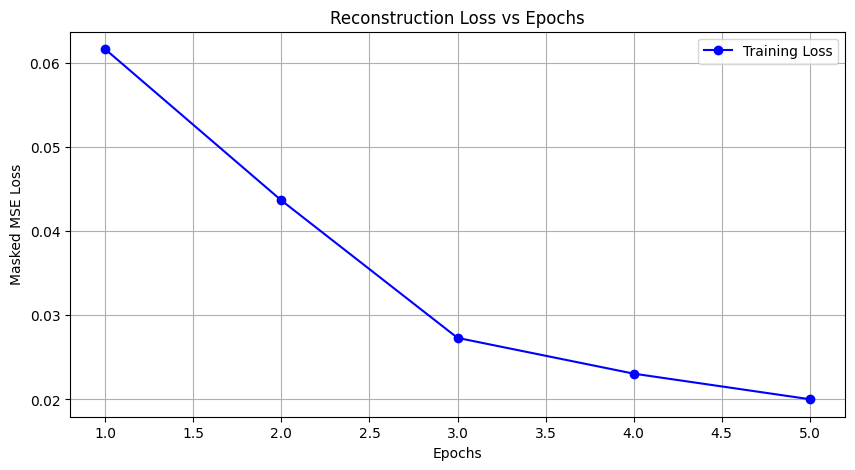

In [18]:
# ==========================================
# PHASE 6: THE TRAINING LOOP
# ==========================================
import time

# List to save the average loss of each epoch for plotting later
epoch_losses = []

# For the final assignment, you might want to run 30-50 epochs.
# But for testing right now, let's just do 5 epochs so you don't have to wait hours!
NUM_EPOCHS = 5 

print("🚀 Starting Training...")

for epoch in range(NUM_EPOCHS):
    # Put model in training mode (activates dropout, layernorm properly)
    model.train()
    
    running_loss = 0.0
    start_time = time.time()
    
    # Loop through batches in the dataloader
    for batch_idx, (batch_images, _) in enumerate(train_loader):
        
        # 1. Move images to the GPU
        batch_images = batch_images.to(device)
        
        # 2. Clear old gradients from the previous batch
        optimizer.zero_grad()
        
        # 3. Forward Pass using Mixed Precision (saves memory & time)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            # Pass images through the MAE model
            preds, targets, mask = model(batch_images)
            
            # Calculate the Masked MSE Loss
            loss = mae_loss(preds, targets, mask)
            
        # 4. Backward Pass using the Scaler (for mixed precision)
        scaler.scale(loss).backward()
        
        # (Optional but Recommended) Gradient Clipping
        # Prevents gradients from "exploding" (getting too large and breaking the model)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 5. Update the Model Weights
        scaler.step(optimizer)
        scaler.update()
        
        # Add the loss to our running total
        running_loss += loss.item()
        
        # Print progress every 200 batches so we know it hasn't crashed
        if (batch_idx + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")
            
    # Step the learning rate scheduler at the end of every epoch
    scheduler.step()
    
    # Calculate average loss for this epoch
    avg_epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_epoch_loss)
    
    end_time = time.time()
    epoch_mins = (end_time - start_time) / 60
    
    print(f"✅ Epoch {epoch+1} Completed | Avg Loss: {avg_epoch_loss:.4f} | Time: {epoch_mins:.2f} mins")

print("🎉 Training Finished!")

# ==========================================
# DELIVERABLE 2: PLOT RECONSTRUCTION LOSS
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), epoch_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Masked MSE Loss')
plt.title('Reconstruction Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# ==========================================
# PHASE 7: EVALUATION & METRICS
# ==========================================
import math
import numpy as np
from skimage.metrics import structural_similarity as ssim

# Step 44: Un-patchify (Reconstruction)
def unpatchify(x, patch_size=16, img_size=224):
    """
    Turns [Batch, 196, 768] back into [Batch, 3, 224, 224]
    This is the exact mathematical reverse of our patchify function!
    """
    p = patch_size
    h = w = img_size // p # 14
    
    # 1. Reshape to separate patch dimensions
    # Shape becomes [Batch, 14, 14, 16, 16, 3]
    x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
    
    # 2. Swap axes to group channels and spatial dimensions correctly
    # 'nhwpqc->nchpwq'
    x = torch.einsum('nhwpqc->nchpwq', x)
    
    # 3. Flatten the spatial dimensions to get final image
    # Shape becomes [Batch, 3, 224, 224]
    imgs = x.reshape(shape=(x.shape[0], 3, h * p, w * p))
    return imgs

print("--- Testing Phase 7 (Metrics) ---")

# Step 43: Validation Forward Pass
model.eval() # Put model in evaluation mode (turns off dropout, etc.)

# Grab one batch from validation set
val_iterator = iter(val_loader)
val_images, _ = next(val_iterator)
val_images = val_images.to(device)

with torch.no_grad(): # No gradients needed for evaluation, saves memory!
    # Forward pass
    preds, targets, mask = model(val_images)
    
    # --- PRO TIP FOR MAE ---
    # The model predicts ALL patches. But for the final image, we already KNOW
    # what the visible patches look like! So, we replace the model's guesses for 
    # the visible patches with the ACTUAL original pixels. 
    # mask=1 means hidden (use prediction), mask=0 means visible (use original).
    mask_expanded = mask.unsqueeze(-1).repeat(1, 1, targets.shape[2])
    final_reconstruction = preds * mask_expanded + targets * (1 - mask_expanded)
    
    # Unpatchify the 1D sequences back to 2D images
    recon_imgs = unpatchify(final_reconstruction)
    orig_imgs = unpatchify(targets)

# Step 45 & 46: Calculate PSNR & SSIM
# Move tensors to CPU and convert to Numpy arrays for calculation
recon_np = recon_imgs.cpu().numpy()
orig_np = orig_imgs.cpu().numpy()

batch_psnr = 0.0
batch_ssim = 0.0
num_images = len(recon_np)

for i in range(num_images):
    # PyTorch uses (C, H, W). skimage wants (H, W, C).
    img_orig = np.transpose(orig_np[i], (1, 2, 0))
    img_recon = np.transpose(recon_np[i], (1, 2, 0))
    
    # Clip values to make sure they stay exactly between 0.0 and 1.0
    img_orig = np.clip(img_orig, 0.0, 1.0)
    img_recon = np.clip(img_recon, 0.0, 1.0)
    
    # Calculate MSE for PSNR
    mse = np.mean((img_orig - img_recon) ** 2)
    if mse == 0:
        psnr = 100.0 # Perfect match
    else:
        # PSNR formula
        psnr = 20 * math.log10(1.0) - 10 * math.log10(mse)
        
    # Calculate SSIM
    # channel_axis=-1 tells it the colors are in the last dimension
    ssim_val = ssim(img_orig, img_recon, data_range=1.0, channel_axis=-1)
    
    batch_psnr += psnr
    batch_ssim += ssim_val

# Get averages
avg_psnr = batch_psnr / num_images
avg_ssim = batch_ssim / num_images

print(f"Deliverable 3: Quantitative Evaluation Complete!")
print(f"Validation PSNR Score: {avg_psnr:.2f} dB")
print(f"Validation SSIM Score: {avg_ssim:.4f}")

--- Testing Phase 7 (Metrics) ---
Deliverable 3: Quantitative Evaluation Complete!
Validation PSNR Score: 19.89 dB
Validation SSIM Score: 0.5995


--- Step 47 & 48: Visualizing 5 Examples ---


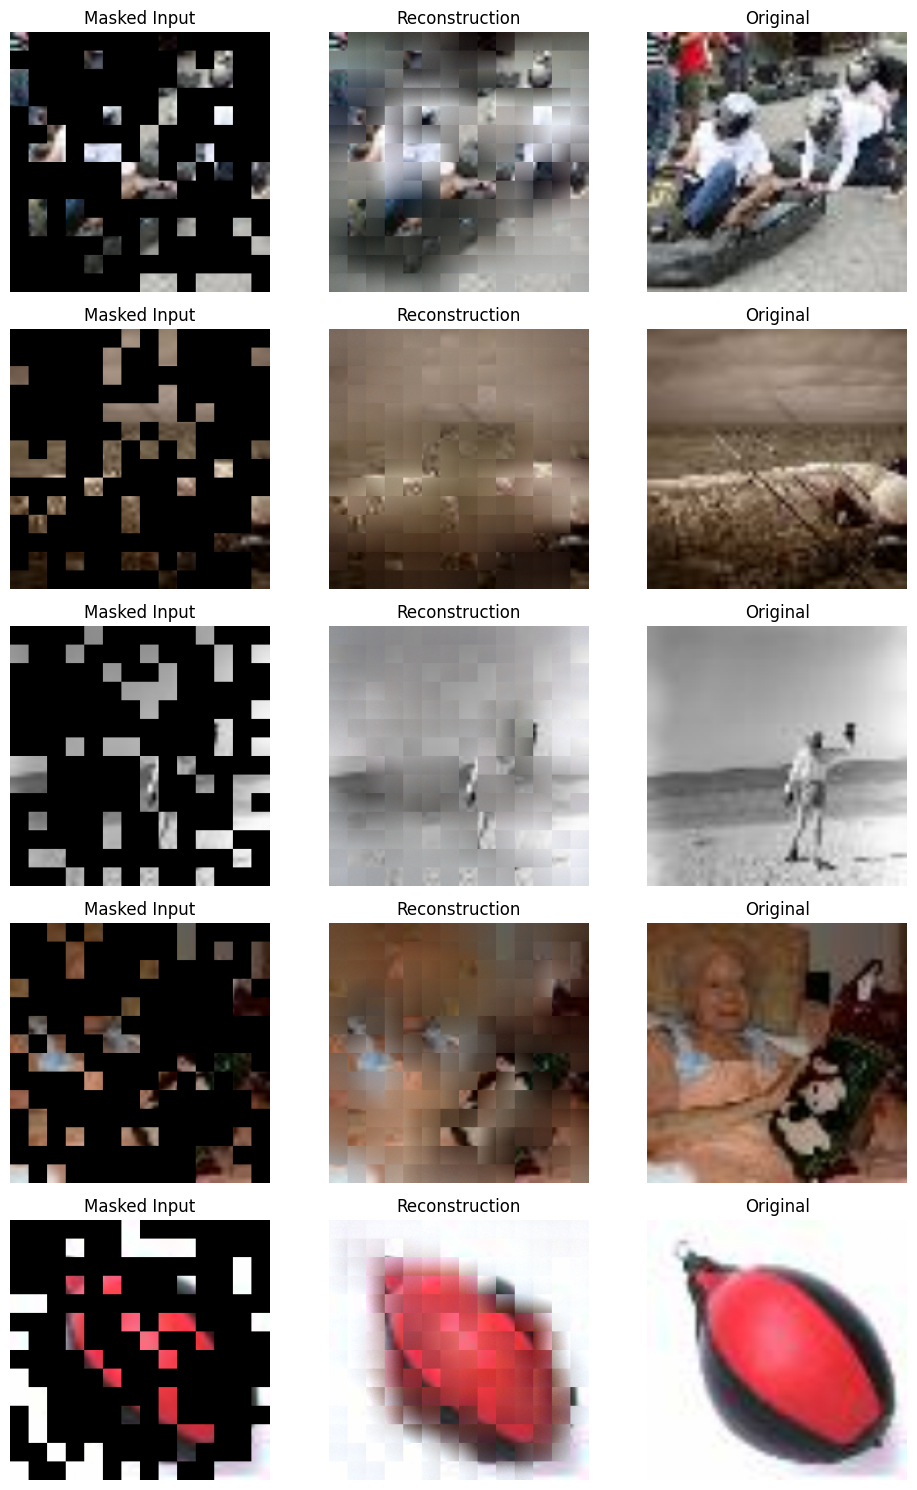

Saving model weights for the local Streamlit App...
✅ Model saved successfully as 'mae_model.pth'!
👉 INSTRUCTION: Go to the right sidebar in Kaggle -> Data -> Output, and download 'mae_model.pth'


In [20]:
# ==========================================
# PHASE 8 (Part A): VISUALIZATION & SAVING
# ==========================================
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

print("--- Step 47 & 48: Visualizing 5 Examples ---")

# Let's write a utility function to show Masked, Reconstructed, and Original
def visualize_reconstructions(model, dataloader, device, num_samples=5):
    model.eval()
    
    # Get a batch
    data_iterator = iter(dataloader)
    images, _ = next(data_iterator)
    images = images.to(device)
    
    with torch.no_grad():
        preds, targets, mask = model(images)
        
        # Expand mask to match pixel dimensions
        mask_expanded = mask.unsqueeze(-1).repeat(1, 1, targets.shape[2])
        
        # 1. Masked Input (Show original patches where visible, 0 where hidden)
        masked_input = targets * (1 - mask_expanded)
        masked_imgs = unpatchify(masked_input).cpu().numpy()
        
        # 2. Final Reconstruction (Combine predictions + original visible patches)
        final_recon = preds * mask_expanded + targets * (1 - mask_expanded)
        recon_imgs = unpatchify(final_recon).cpu().numpy()
        
        # 3. Original Ground Truth
        orig_imgs = unpatchify(targets).cpu().numpy()

    # Plot exactly 5 samples
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))
    
    for i in range(num_samples):
        # Convert to Displayable format (H, W, C) and clip
        img_masked = np.clip(np.transpose(masked_imgs[i], (1, 2, 0)), 0, 1)
        img_recon = np.clip(np.transpose(recon_imgs[i], (1, 2, 0)), 0, 1)
        img_orig = np.clip(np.transpose(orig_imgs[i], (1, 2, 0)), 0, 1)
        
        # Masked Input
        axes[i, 0].imshow(img_masked)
        axes[i, 0].set_title("Masked Input")
        axes[i, 0].axis('off')
        
        # Reconstruction
        axes[i, 1].imshow(img_recon)
        axes[i, 1].set_title("Reconstruction")
        axes[i, 1].axis('off')
        
        # Original
        axes[i, 2].imshow(img_orig)
        axes[i, 2].set_title("Original")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('reconstructions_comparison.png') # Saves the image to Kaggle
    plt.show()

# Run the visualization
visualize_reconstructions(model, val_loader, device, num_samples=5)

# ==========================================
# STEP 49 Prep: Save Model for Local Use
# ==========================================
print("Saving model weights for the local Streamlit App...")
torch.save(model.state_dict(), 'mae_model.pth')
print("✅ Model saved successfully as 'mae_model.pth'!")
print("👉 INSTRUCTION: Go to the right sidebar in Kaggle -> Data -> Output, and download 'mae_model.pth'")